In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import ViT_B_16_Weights
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print(f"Device : {device}")
print(f"Seed   : {SEED}")

if torch.cuda.is_available():
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU    : {torch.cuda.get_device_name(0)} ({vram_total:.1f} GB VRAM)")

Device : cuda
Seed   : 42
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB VRAM)


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('augmented_dataset/train', transform=transform)
val_dataset   = datasets.ImageFolder('augmented_dataset/val',   transform=transform)
test_dataset  = datasets.ImageFolder('augmented_dataset/test',  transform=transform)

# Smaller batch size to stay within 6 GB VRAM
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train : {len(train_dataset)} images")
print(f"Val   : {len(val_dataset)} images")
print(f"Test  : {len(test_dataset)} images")
print(f"Classes: {train_dataset.classes}")
print(f"Batch size: {batch_size}")

Train : 13569 images
Val   : 959 images
Test  : 962 images
Classes: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
Batch size: 16


In [3]:
train_labels  = [label for _, label in train_dataset.samples]
class_counts  = np.bincount(train_labels)
print(f"Train class distribution: {dict(zip(train_dataset.classes, class_counts))}")

class_weights = 1.0 / (torch.tensor(class_counts, dtype=torch.float) + 1e-5)
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights = class_weights.to(device)
print(f"Loss weights: {class_weights.cpu().numpy().round(4)}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

Train class distribution: {'MildDemented': np.int64(1881), 'ModerateDemented': np.int64(264), 'NonDemented': np.int64(6720), 'VeryMildDemented': np.int64(4704)}
Loss weights: [0.4543 3.2369 0.1272 0.1817]


In [4]:
# Load ViT-B/16 pretrained on ImageNet
model_vit = models.vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

# Freeze all transformer blocks
for param in model_vit.parameters():
    param.requires_grad = False

# Unfreeze the last 3 encoder blocks
blocks_to_unfreeze = ['encoder_layer_9', 'encoder_layer_10', 'encoder_layer_11']
for name, param in model_vit.encoder.layers.named_parameters():
    if any(block in name for block in blocks_to_unfreeze):
        param.requires_grad = True

# Replace classification head
num_features = model_vit.heads.head.in_features
model_vit.heads = nn.Sequential(
    nn.LayerNorm(num_features),
    nn.Linear(num_features, 256),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(256, 4)
)
model_vit = model_vit.to(device)

# Low learning rates — transformers are sensitive to LR
optimizer_vit = optim.AdamW([
    {'params': [p for n, p in model_vit.encoder.layers.named_parameters()
                if p.requires_grad], 'lr': 5e-5},
    {'params': model_vit.heads.parameters(), 'lr': 5e-4}
], weight_decay=0.01)

scheduler_vit = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_vit, 
    mode='min', 
    factor=0.5, 
    patience=2
)

trainable = sum(p.numel() for p in model_vit.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_vit.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,}")
print(f"Model loaded on: {device}")

Trainable parameters: 21,463,044 / 85,998,084
Model loaded on: cuda


In [5]:
WARM_START_PATH = None   # ← change to None to start cold

import os
if WARM_START_PATH and os.path.exists(WARM_START_PATH):
    model_vit.load_state_dict(torch.load(WARM_START_PATH, map_location=device))
    print(f"Warm-start: loaded weights from '{WARM_START_PATH}'")
    print("The model will fine-tune from its previous state — expect fast convergence.")
else:
    if WARM_START_PATH:
        print(f"Warning: '{WARM_START_PATH}' not found — starting from ImageNet weights.")
    else:
        print("Cold start: using ImageNet pretrained weights.")

Cold start: using ImageNet pretrained weights.


In [6]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, save_path, scheduler=None):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')

    scaler = torch.cuda.amp.GradScaler()
    
    for epoch in range(1, epochs + 1):
        start = time.time()

        model.train()
        train_loss, train_correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
                
            scaler.scale(loss).backward()
            
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            scaler.step(optimizer)
            scaler.update()
            
            train_loss    += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_train_loss = train_loss / len(train_loader.dataset)
        epoch_train_acc  = train_correct / len(train_loader.dataset)

        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc  = val_correct / len(val_loader.dataset)

        checkpoint_msg = ''
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), save_path)
            checkpoint_msg = '  ← best'

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        vram_used = torch.cuda.memory_allocated() / 1e9 if torch.cuda.is_available() else 0
        elapsed   = time.time() - start
        print(f"Epoch {epoch:2d}/{epochs} | {int(elapsed//60)}m {int(elapsed%60)}s | "
              f"Train loss {epoch_train_loss:.4f} acc {epoch_train_acc:.4f} | "
              f"Val loss {epoch_val_loss:.4f} acc {epoch_val_acc:.4f} | "
              f"VRAM {vram_used:.2f}GB{checkpoint_msg}")
        if scheduler is not None:
            scheduler.step(epoch_val_loss)

    model.load_state_dict(torch.load(save_path))
    print(f"\nBest val loss: {best_val_loss:.4f} — weights loaded from '{save_path}'")
    return history

In [7]:
# Warm-start → 10 epochs is usually enough (model already knows MRI features).
# If you set WARM_START_PATH = None above, increase this to 30.
EPOCHS = 10 if (WARM_START_PATH and os.path.exists(WARM_START_PATH)) else 30

print(f"Starting ViT-B/16 training ({EPOCHS} epochs)...")
history_vit = train_model(
    model_vit, train_loader, val_loader, criterion, optimizer_vit,
    epochs=EPOCHS, save_path='vit.pth',
    scheduler=scheduler_vit
)

Starting ViT-B/16 training (30 epochs)...


C:\Users\luism\AppData\Local\Temp\ipykernel_27496\1889370045.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\luism\AppData\Local\Temp\ipykernel_27496\1889370045.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch  1/30 | 1m 48s | Train loss 0.8719 acc 0.5888 | Val loss 0.7677 acc 0.6767 | VRAM 0.63GB  ← best
Epoch  2/30 | 2m 20s | Train loss 0.3603 acc 0.8192 | Val loss 0.3710 acc 0.8509 | VRAM 0.63GB  ← best
Epoch  3/30 | 2m 50s | Train loss 0.1569 acc 0.9316 | Val loss 0.2602 acc 0.9239 | VRAM 0.63GB  ← best
Epoch  4/30 | 2m 51s | Train loss 0.0656 acc 0.9769 | Val loss 0.5735 acc 0.9145 | VRAM 0.63GB
Epoch  5/30 | 2m 44s | Train loss 0.0459 acc 0.9859 | Val loss 0.3922 acc 0.9281 | VRAM 0.63GB
Epoch  6/30 | 3m 5s | Train loss 0.0552 acc 0.9868 | Val loss 0.3303 acc 0.9374 | VRAM 0.63GB
Epoch  7/30 | 3m 1s | Train loss 0.0049 acc 0.9980 | Val loss 0.3000 acc 0.9572 | VRAM 0.63GB
Epoch  8/30 | 2m 48s | Train loss 0.0033 acc 0.9993 | Val loss 0.2635 acc 0.9656 | VRAM 0.63GB
Epoch  9/30 | 3m 9s | Train loss 0.0124 acc 0.9971 | Val loss 0.4663 acc 0.9385 | VRAM 0.63GB
Epoch 10/30 | 3m 12s | Train loss 0.0016 acc 0.9993 | Val loss 0.2156 acc 0.9698 | VRAM 0.63GB  ← best
Epoch 11/30 | 2m 51s 

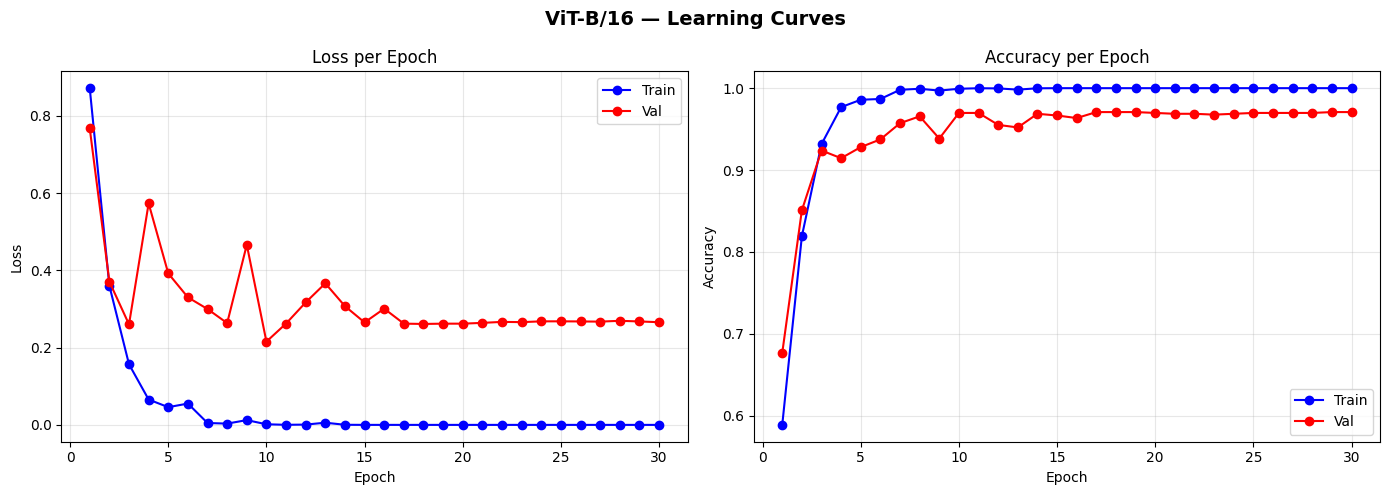

Saved: vit_curves.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ViT-B/16 — Learning Curves', fontsize=14, fontweight='bold')

epochs_range = range(1, len(history_vit['train_loss']) + 1)

axes[0].plot(epochs_range, history_vit['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs_range, history_vit['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_vit['train_acc'], 'b-o', label='Train')
axes[1].plot(epochs_range, history_vit['val_acc'],   'r-o', label='Val')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vit_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vit_curves.png")